In [6]:
import pandas as pd
import re

def classify_subreddit(text):
    # Keywords and patterns for stress classification
    stress_keywords = [
        'anxiety', 'panic attack', 'anxious', 'nervous', 'overthinking', 
        'work stress', 'social anxiety', 'performance anxiety', 'exam stress', 
        'job stress', 'relationship anxiety', 'health anxiety'
    ]
    
    # Keywords and patterns for trauma classification
    trauma_keywords = [
        'abuse', 'ptsd', 'sexual abuse', 'childhood trauma', 'assault', 
        'domestic violence', 'child abuse', 'emotional abuse', 'traumatic', 
        'rape', 'molestation', 'psychological abuse', 'physical abuse'
    ]
    
    # Convert text to lowercase for case-insensitive matching
    text_lower = text.lower()
    
    # Check for trauma keywords first (as trauma is more severe)
    for keyword in trauma_keywords:
        if keyword in text_lower:
            return 'trauma'
    
    # Then check for stress keywords
    for keyword in stress_keywords:
        if keyword in text_lower:
            return 'stress'
    
    # Default to stress if no clear classification
    return 'stress'

# Read the input CSV
df = pd.read_csv('stress analysis.csv')

# Classify subreddits
df['category'] = df['subreddit'].apply(classify_subreddit)

# Save the classified CSV
df.to_csv('classified_subreddits.csv', index=False)

print(df['category'].value_counts())

category
stress    345
trauma     85
Name: count, dtype: int64


In [14]:
df = pd.read_csv('classified_subreddits.csv')
print(df['label'].value_counts())

label
trauma    269
stress    161
Name: count, dtype: int64


In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [22]:
print(classification_report(df['label'], df['category']))
print(confusion_matrix(df['label'], df['category']))

              precision    recall  f1-score   support

      stress       0.47      1.00      0.64       161
      trauma       1.00      0.32      0.48       269

    accuracy                           0.57       430
   macro avg       0.73      0.66      0.56       430
weighted avg       0.80      0.57      0.54       430

[[161   0]
 [184  85]]


### asking claude to train itself with 75% of the data and then predict the rest 25%

Classification Report:
              precision    recall  f1-score   support

      stress       1.00      0.04      0.08        47
      trauma       0.58      1.00      0.73        61

    accuracy                           0.58       108
   macro avg       0.79      0.52      0.41       108
weighted avg       0.76      0.58      0.45       108

[[ 2 45]
 [ 0 61]]

Top 10 Most Informative Features for Stress Classification:
like
anxiety
ve
just
feel
don
äôt
äôm
really
want

Predictions saved to 'stress_predictions.csv'


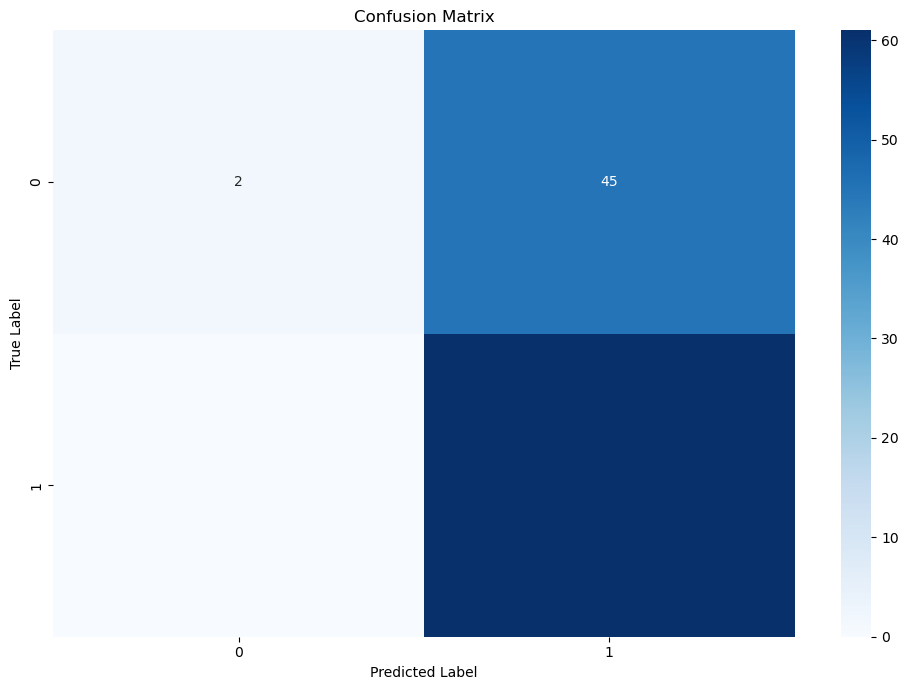

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Read the CSV file
df = pd.read_csv('stress analysis.csv', usecols=['subreddit', 'label'])
# Rename the column to match our original script

# Preprocess the data
# We'll use the text in 'subreddit' column as features 
# and 'subreddit.1' as the target variable
X = df['subreddit']
y = df['label']

# Split the data into training (75%) and testing (25%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Vectorize the text data using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

# Train a Naive Bayes classifier
classifier = MultinomialNB()
classifier.fit(X_train_vectorized, y_train)

# Make predictions
y_pred = classifier.predict(X_test_vectorized)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# Create a confusion matrix
plt.figure(figsize=(10,7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')

# Get feature importance
feature_names = vectorizer.get_feature_names_out()
top_features = np.argsort(classifier.feature_log_prob_[0])[::-1]

print("\nTop 10 Most Informative Features for Stress Classification:")
for i in range(10):
    print(f"{feature_names[top_features[i]]}")

# Save predictions to a CSV
predictions_df = pd.DataFrame({
    'Original_Text': X_test,
    'True_Label': y_test,
    'Predicted_Label': y_pred
})
predictions_df.to_csv('stress_predictions.csv', index=False)
print("\nPredictions saved to 'stress_predictions.csv'")
